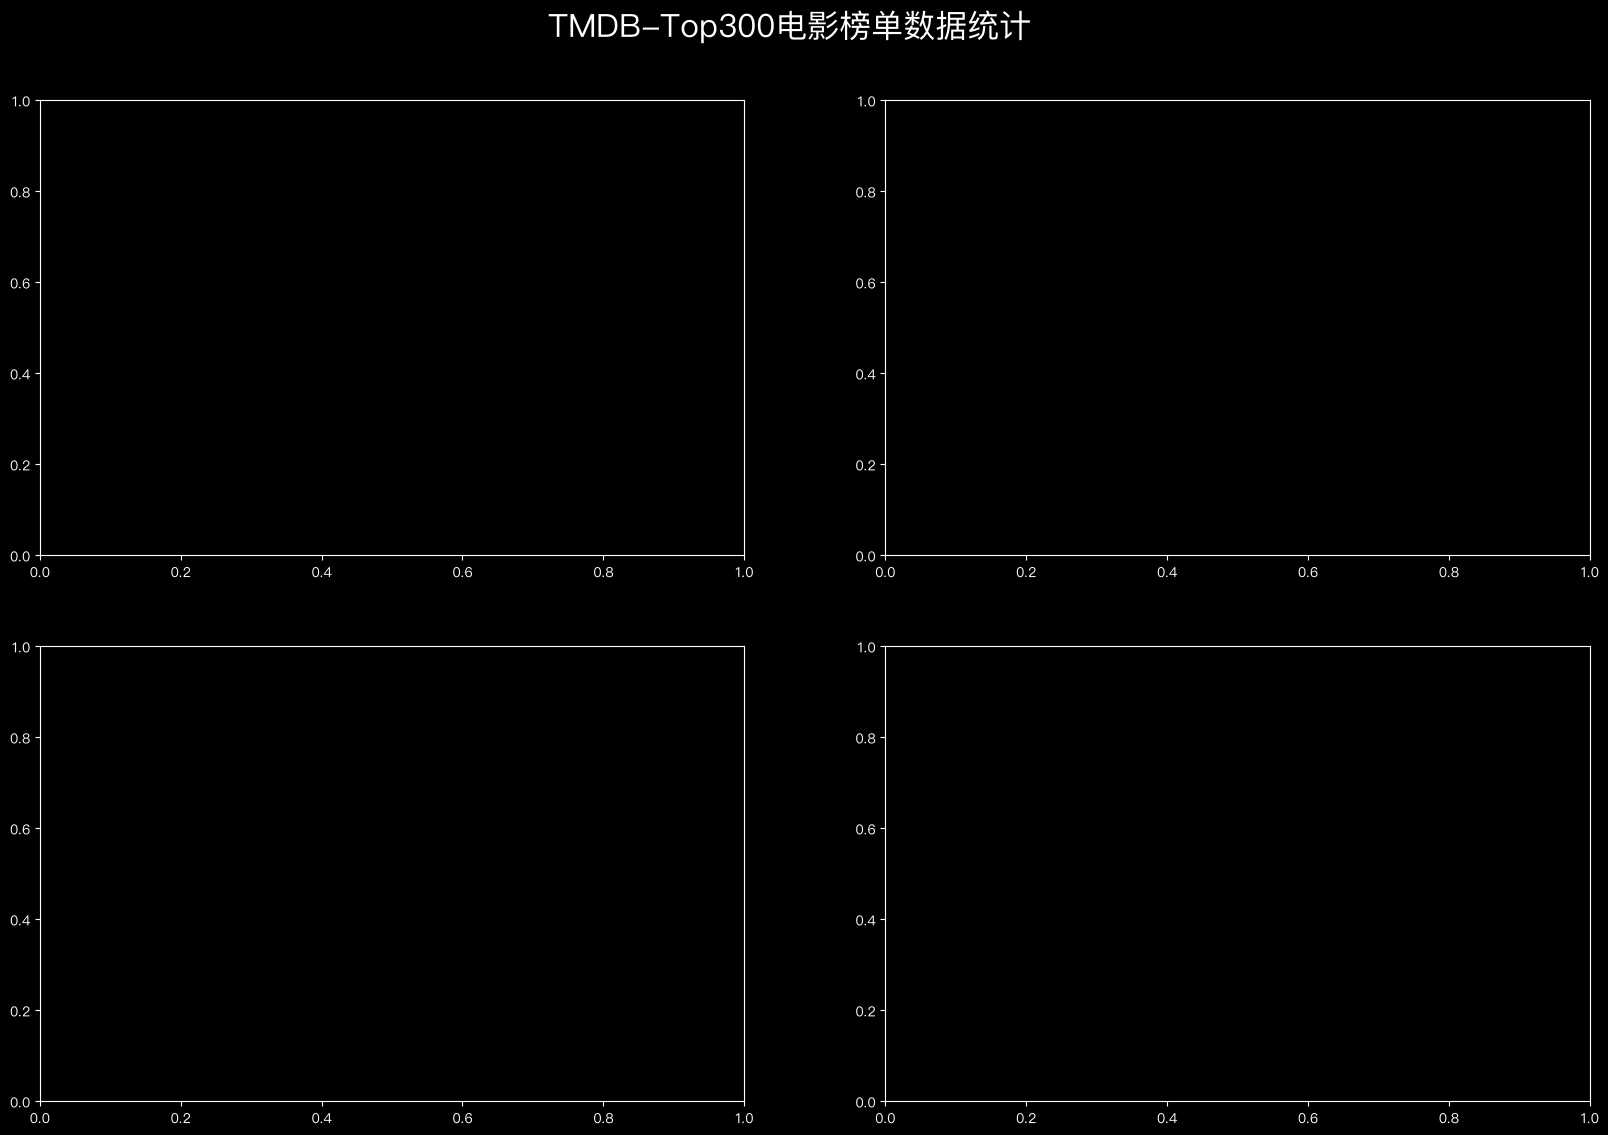

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axisartist import Axes

plt.rcParams['font.sans-serif'] = ['PingFang SC']

#创建子图
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20,13),dpi=100)

#添加画布标题
fig.suptitle('TMDB-Top300电影榜单数据统计',fontsize=23,x=0.5,y=0.95)

#获取子图
axes1:Axes = axes[0][0]
axes2:Axes = axes[0][1]
axes3:Axes = axes[1][0]
axes4:Axes = axes[1][1]

#加载数据
cols = ['电影名', '年份', '上映时间', '类型', '时长', '评分', '语言']  # 需要保留的列
data = pd.read_csv('data/movies.csv')

data.columns = data.columns.str.strip()  # 去掉列名两边空格
#ValueError报错了 原:data = pd.read_csv('data/movies.csv',nrows=30,usecols=['电影名', '年份', '上映时间', '类型', '时长', '评分', '语言'])

data = data[cols]  # 选择需要的列

data['年份'] = data['年份'].astype('Int64')  # 将年份转成支持空值的整数类型
#int64 : 整型数字(不支持空值), Int64 : 整型数字(支持空值),float64: 浮点型数字(支持空值)


In [24]:
#1.需求一: 统计TOP300的电影中,每一年上映的电影数量的变化(折线图)

#1.1 缺失值,异常值处理
data.isnull().sum() #data.isnull().sum和data.isnull().sum()的区别: 方法不加()只是取方法本身；加()才会执行方法'''
data['年份'] = data['年份'].fillna(data['上映时间'].str[0:4:1])#嵌套 为变量更新赋值 年份=上映时间前四位数 字符串切片
data.head(30)
# data[data['年份']<0] 异常值校验

,电影名,年份,上映时间,类型,时长,评分,语言
0,肖申克的救赎,1994,1994-09-23,"剧情,犯罪",142,87,英语
1,教父,1972,1972-03-24,"剧情,犯罪",175,87,英语
2,教父2,1974,1974-12-20,"剧情,犯罪",200,86,英语
3,辛德勒的名单,1993,2019-04-06,"剧情,历史,战争",195,86,英语
4,十二怒汉,1957,1957-04-10,剧情,96,86,英语
5,Selena Gomez: My Mind & Me,2022,2022-11-02,"纪录,音乐",95,85,英语
6,¿Quieres ser mi hijo?,2023,2023-09-21,"喜剧,爱情",100,85,英语
7,千与千寻,2001,2019-06-21,"动画,家庭,奇幻",125,85,日语
8,蝙蝠侠：黑暗骑士,2008,2018-04-07,"动作,犯罪,惊悚",152,85,英语
9,勇夺芳心,1995,1995-10-20,"喜剧,剧情,爱情",190,85,印地语


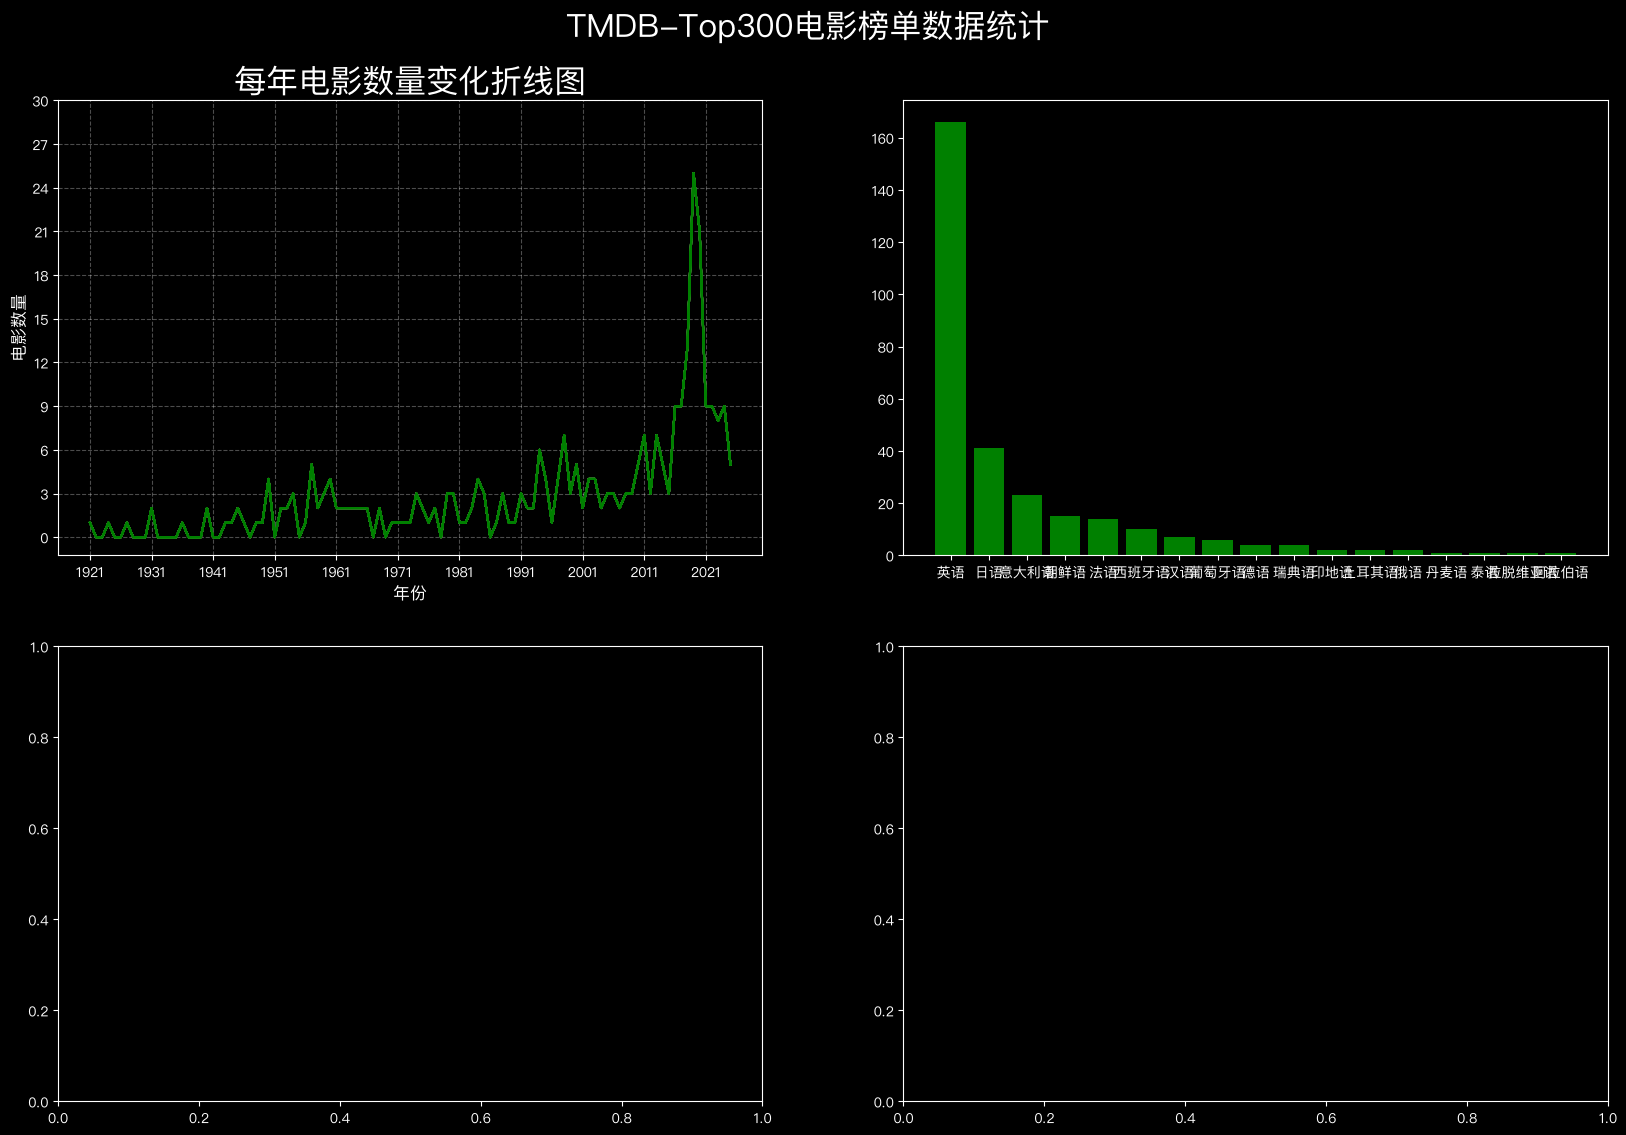

In [42]:
#1.2 分组统计
year_count = data.groupby('年份')['年份'].count()

#1.3 组装数据
#1.31 x轴数据
min_year = year_count.index.min()
max_year = year_count.index.max()
x = [i for i in range(min_year, max_year + 1)]#生成完整年份范围(即使对应年份无上榜电影 应显示对应y=0而不是没有对应x)

#1.32 y轴数据
y = [int(year_count.get(i,0)) for i in x]#遍历x中的年份，从year_count中取对应数量，缺失年份用0填充


#1.4 绘制折线图
axes1.plot(x,y,color='green')

axes1.set_title('每年电影数量变化折线图',fontsize=23)#添加子图标题
axes1.set_xlabel('年份',fontsize=12)
axes1.set_ylabel('电影数量',fontsize=12)
axes1.set_xticks(x[::10])#设置x轴刻度间隔
y_ticks = [i for i in range(0,31,3)]
axes1.set_yticks(y_ticks)#设置y轴刻度间隔
axes1.grid(linestyle='--', alpha=0.3)

display(fig)#显示指定的对象,比起plt.show 可跨单元格显示之前创建的figure

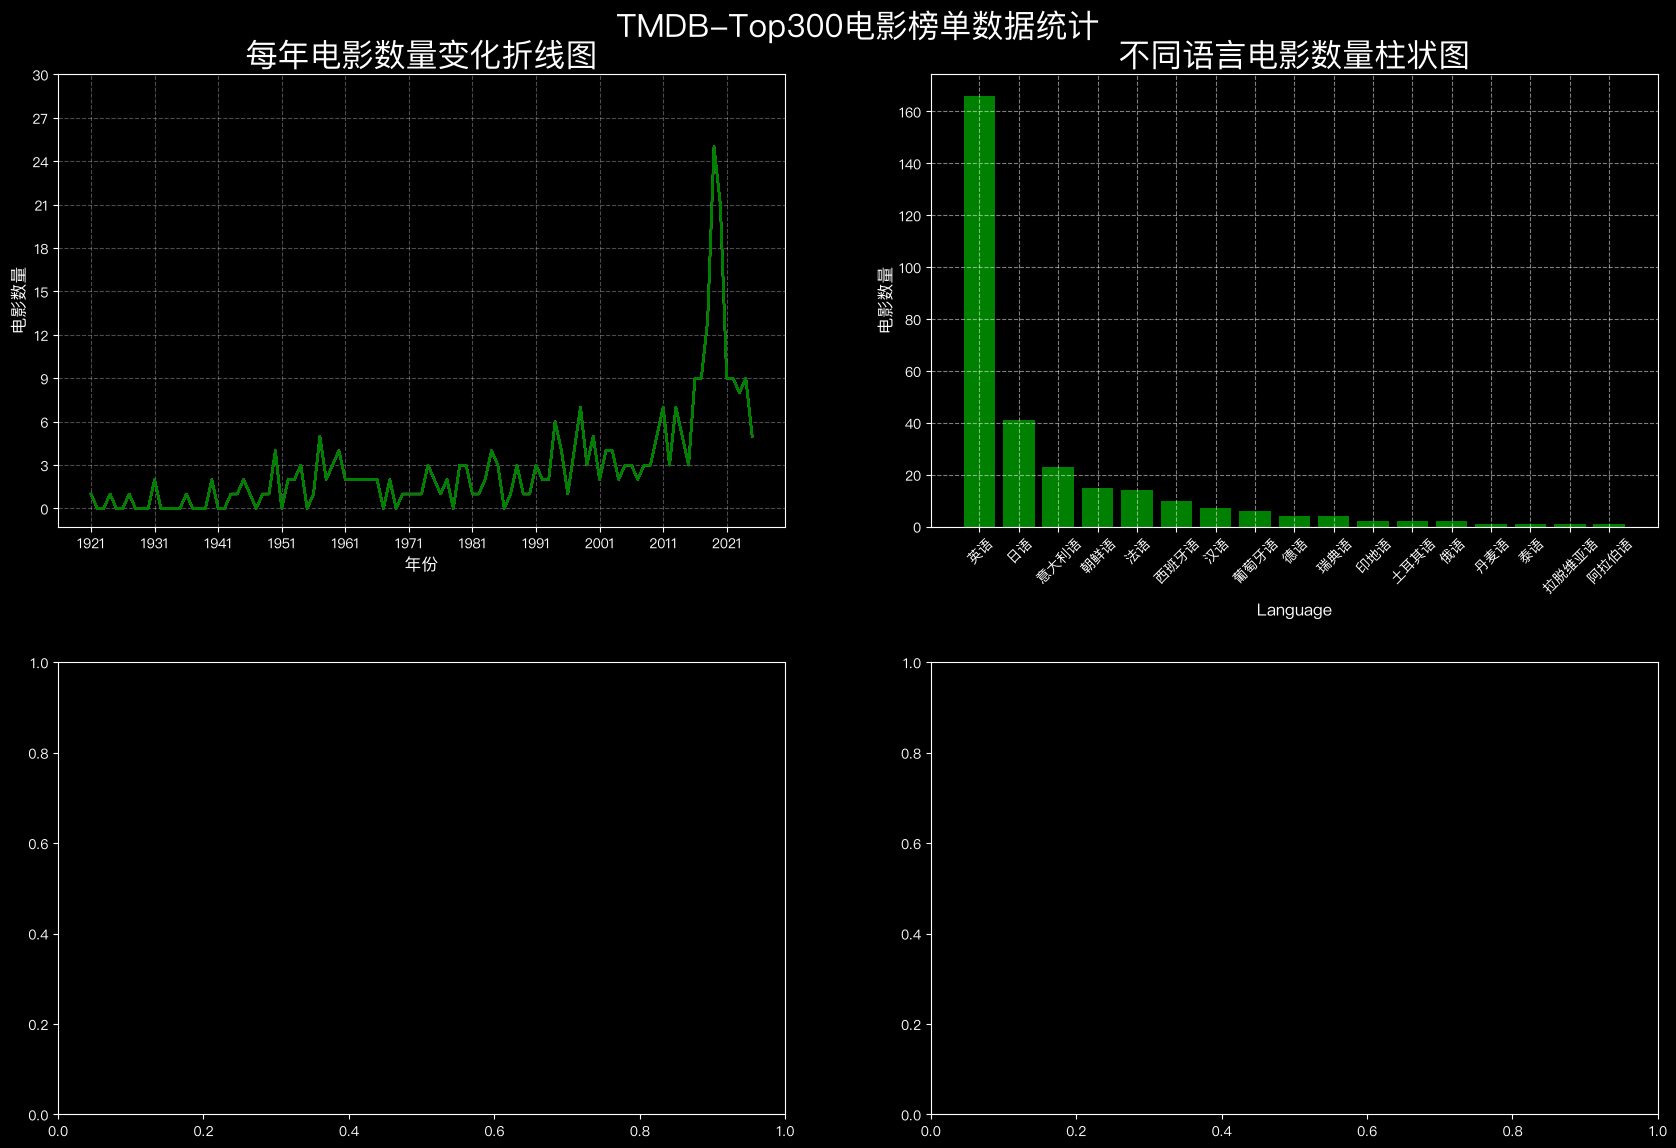

In [49]:
#2. 需求二: 统计对比不同语言的电影数量
language_count = data.groupby('语言')['语言'].count().sort_values(ascending=False)
x_language = language_count.index.tolist()
y_language = language_count.values.tolist()

#2.1 绘制柱状图--bar
axes2.bar(x_language, y_language, color='green',width=0.7)
axes2.set_title('不同语言电影数量柱状图',fontsize=23)
axes2.set_xlabel('Language',fontsize=12)
axes2.set_ylabel('电影数量',fontsize=12)
axes2.grid(linestyle='--', alpha=0.5)
axes2.tick_params(axis='x', rotation=45)#设置axes2的x轴刻度文字旋转90度,避免标签重叠
#tick_params用于设置坐标轴刻度样式，比如刻度文字角度、大小、颜色等
fig.subplots_adjust(hspace=0.3,wspace=0.2)#调整子图间距:hspace控制垂直间距,wspace控制水平间距

display(fig)